In [1]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.combine import SMOTEENN
from sklearn.decomposition import PCA
#Propias
import set_paths
import src.utils as ut

In [2]:
data = pd.read_csv(r'..\data\clean.csv')
features = data.iloc[:, 1:]
target = data.iloc[:, 0]
n_splits = 5
seed = 42
fold_maker = StratifiedKFold(n_splits= n_splits, shuffle= True, random_state= seed)

## Por visualización, se hace uso de PCA a 10 componentes

In [3]:
for train_idx, test_idx in fold_maker.split(features, target):
    x_trn = features.iloc[train_idx]
    y_trn = target.iloc[train_idx]
    n_components = 10
    pca = PCA(n_components= n_components)
    x_trn_reduced = pca.fit_transform(x_trn)
    print(f"Las primeras {n_components} explican el {np.round(sum(pca.explained_variance_ratio_), 2)}% de la varianza")
    test = pd.DataFrame(x_trn_reduced)
    test["Target"] = y_trn

Las primeras 10 explican el 0.99% de la varianza
Las primeras 10 explican el 0.99% de la varianza
Las primeras 10 explican el 0.99% de la varianza
Las primeras 10 explican el 0.99% de la varianza
Las primeras 10 explican el 0.99% de la varianza


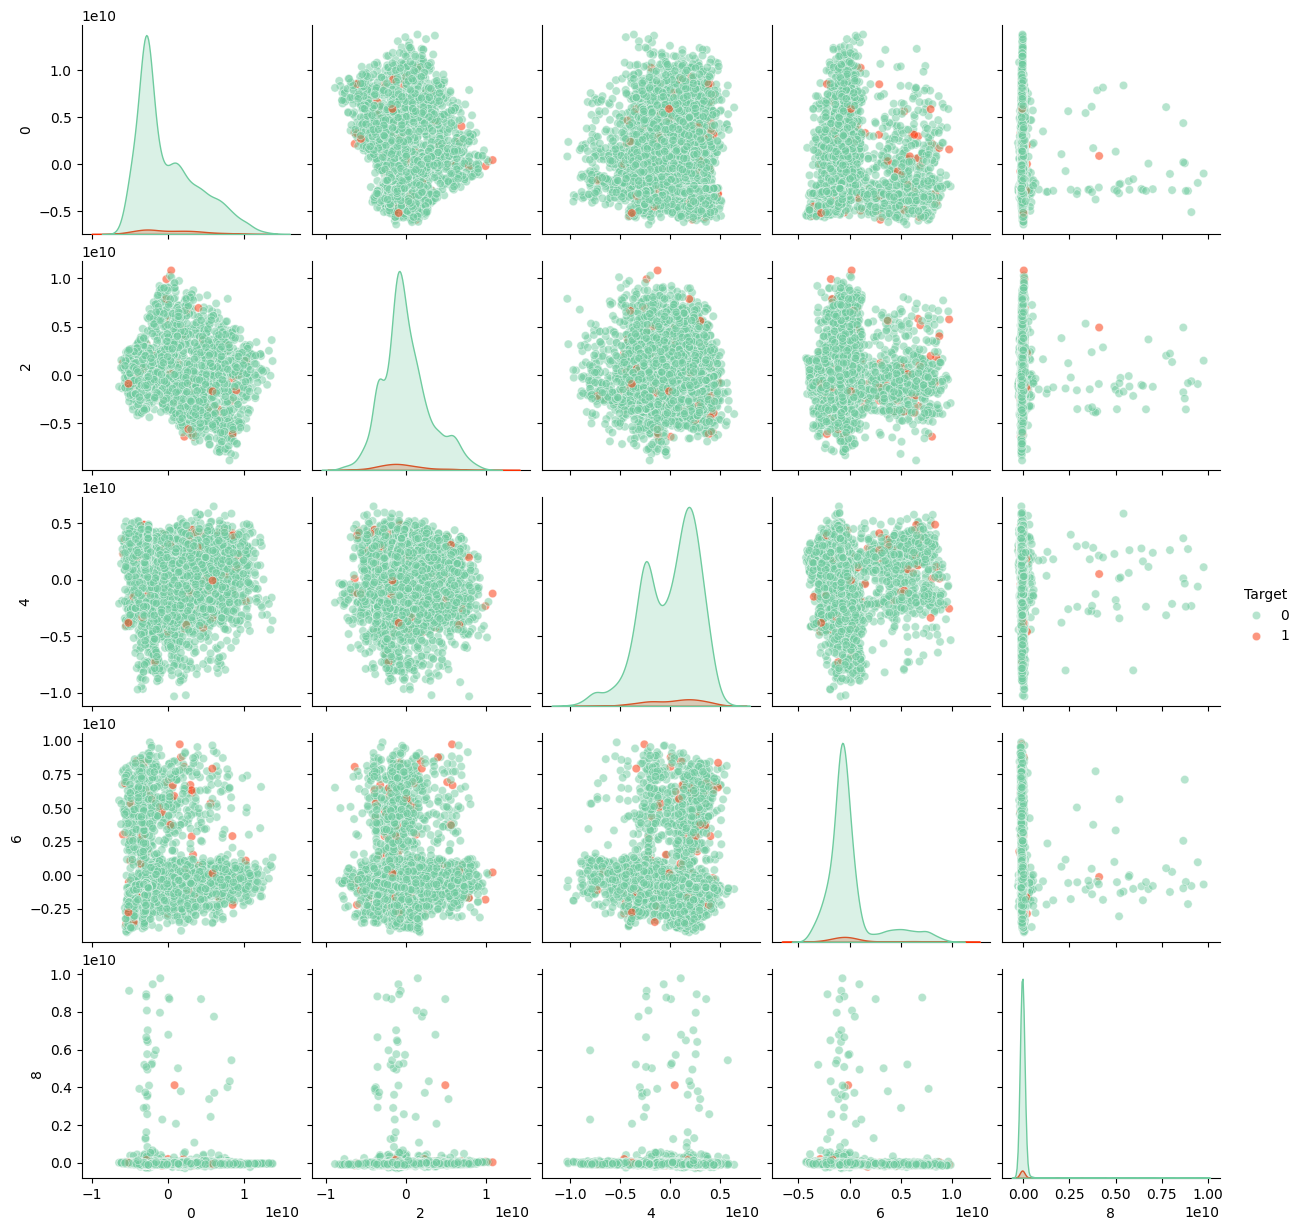

In [4]:
sns.pairplot(data = test.iloc[:, ::2], hue = "Target", hue_order= [0, 1], palette = [ut.color0, ut.color1],
             plot_kws= {"alpha" : 0.5})

##  Las clases están mezcladas, podrían ser difíciles de separar linealmente, hacemos SMOTE-ENN antes del PCA:

In [19]:
for train_idx, test_idx in fold_maker.split(features, target):
    x_trn = features.iloc[train_idx]
    y_train = target.iloc[train_idx]
    smote = BorderlineSMOTE(sampling_strategy= "minority", random_state = 42)
    #enn = EditedNearestNeighbours(sampling_strategy= "all")
    #smoteenn = SMOTEENN(smote = smote, enn = enn)
    x_trn_res, y_train_res = smote.fit_resample(x_trn, y_train)
    n_components = 10
    pca = PCA(n_components= n_components)
    x_trn_reduced = pca.fit_transform(x_trn_res)
    print(f"Las primeras {n_components} explican el {np.round(sum(pca.explained_variance_ratio_), 2)}% de la varianza")
    test = pd.DataFrame(x_trn_reduced)
    test["Target"] = y_train_res  

Las primeras 10 explican el 0.99% de la varianza
Las primeras 10 explican el 0.99% de la varianza
Las primeras 10 explican el 0.99% de la varianza
Las primeras 10 explican el 0.99% de la varianza
Las primeras 10 explican el 0.98% de la varianza


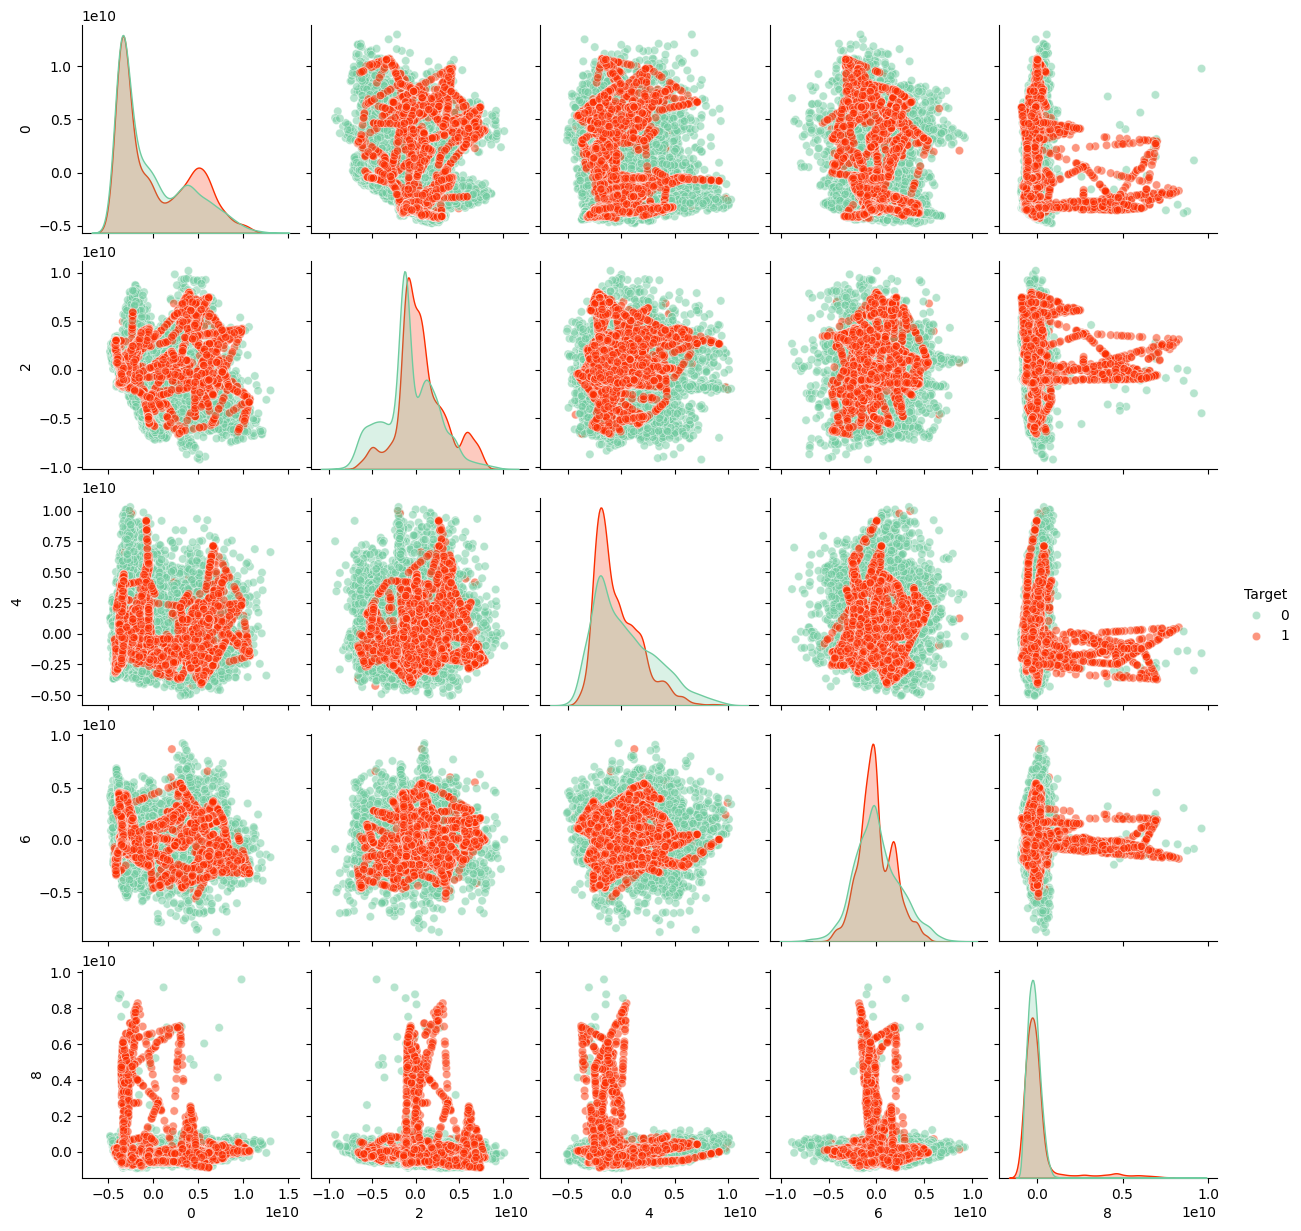

In [20]:
sns.pairplot(data = test.iloc[:, ::2], hue = "Target", hue_order= [0, 1], palette = [ut.color0, ut.color1],
             plot_kws= {"alpha" : 0.5})